# Sauerkirsche Phenology Analysis
This notebook explores the start of the bloom for sour cherries (Sauerkirsche) across DWD stations in Germany.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_parquet('../data/processed/kirschbluete_doy.parquet')
print(f"Total data points: {len(df)}")
df.head()

Total data points: 132563


,Stations_id,Referenzjahr,Jultag
0,7501,1954,132
1,7501,1955,142
2,7501,1956,140
3,7501,1957,125
4,7501,1958,144


## Bloom Start Time over the Years (Longest Running Stations)
Plotting discrete observations (Julian day of bloom start) per year, with one separate diagram per station for better readability.

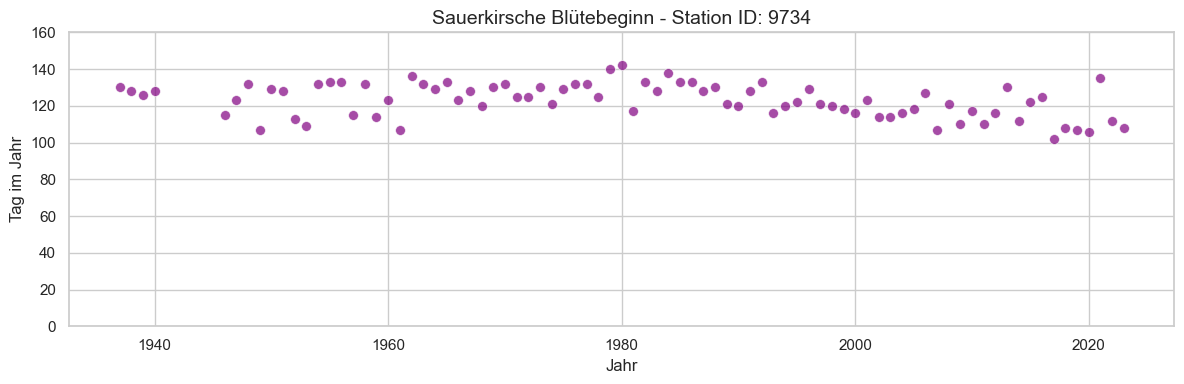

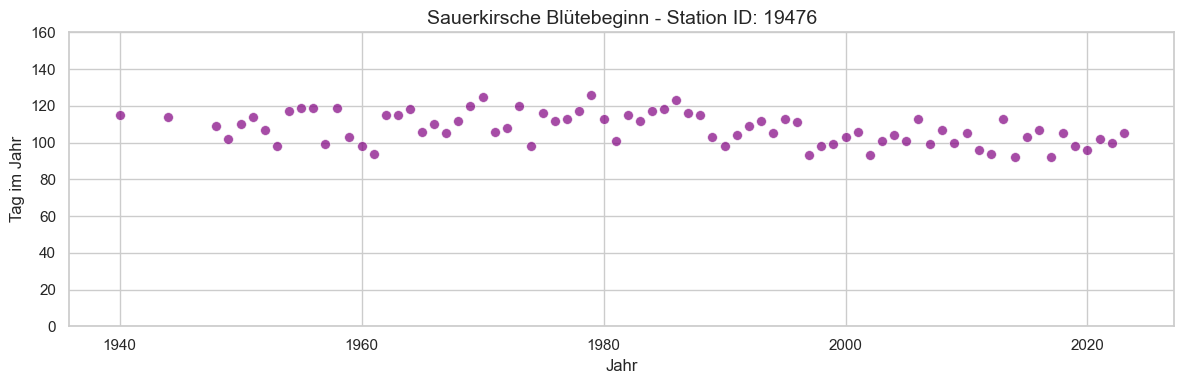

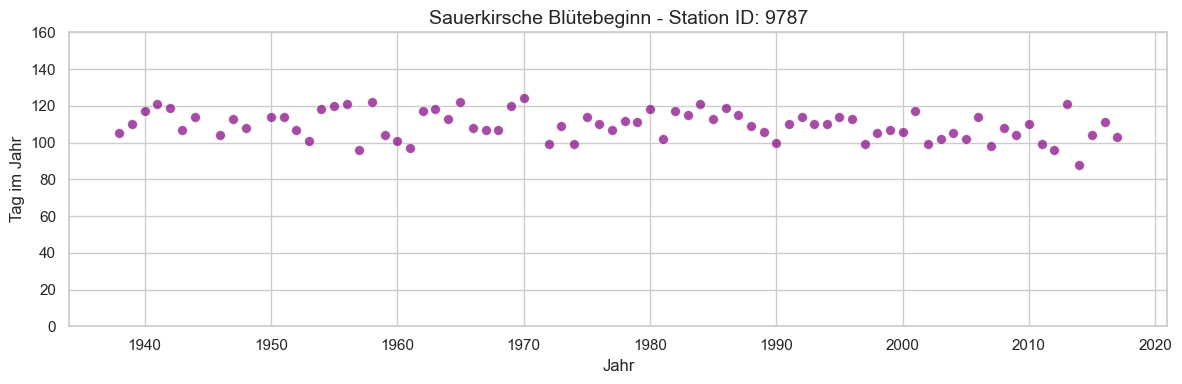

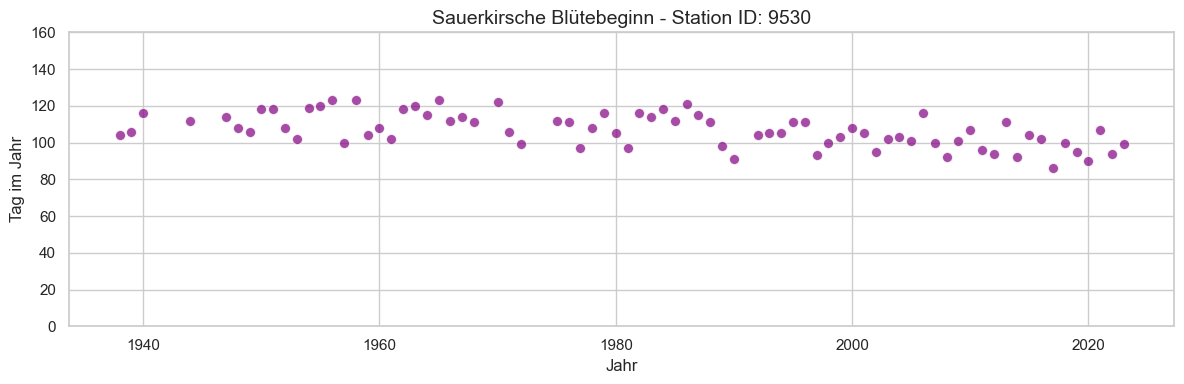

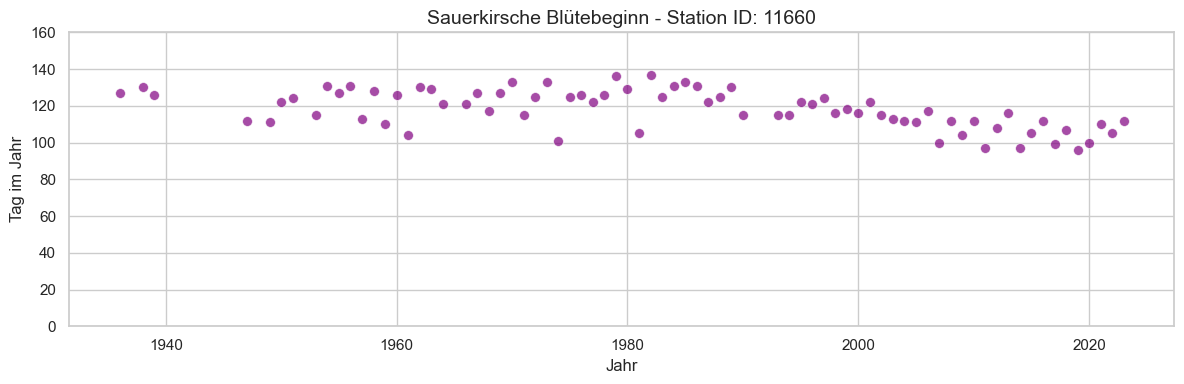

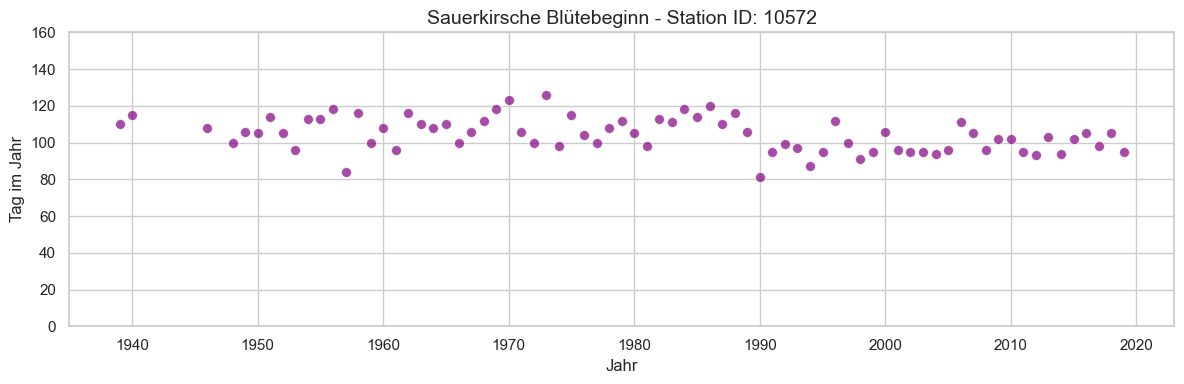

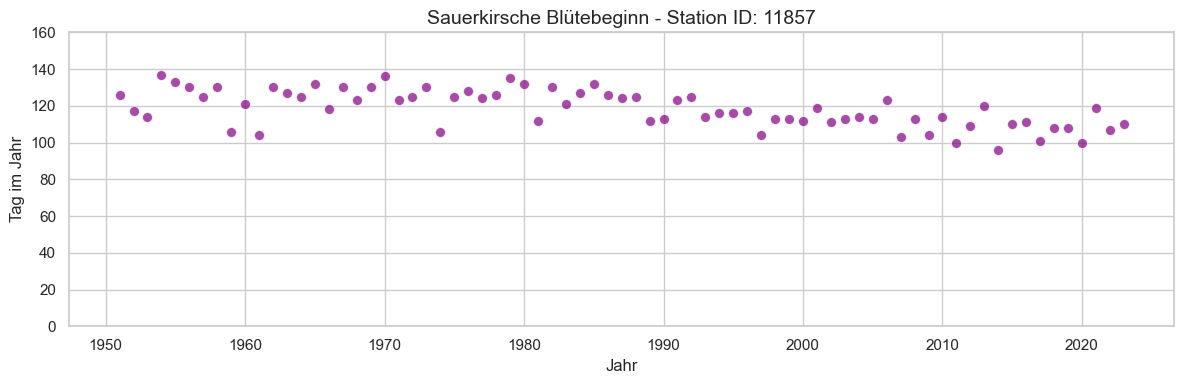

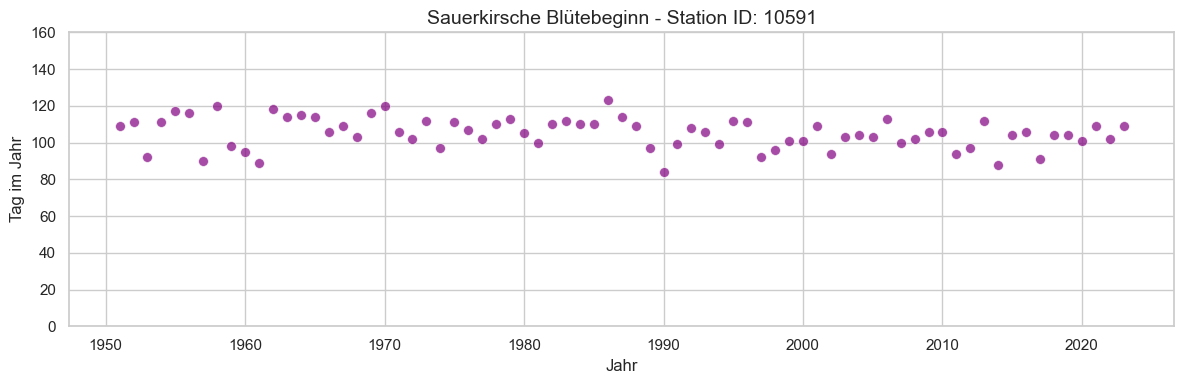

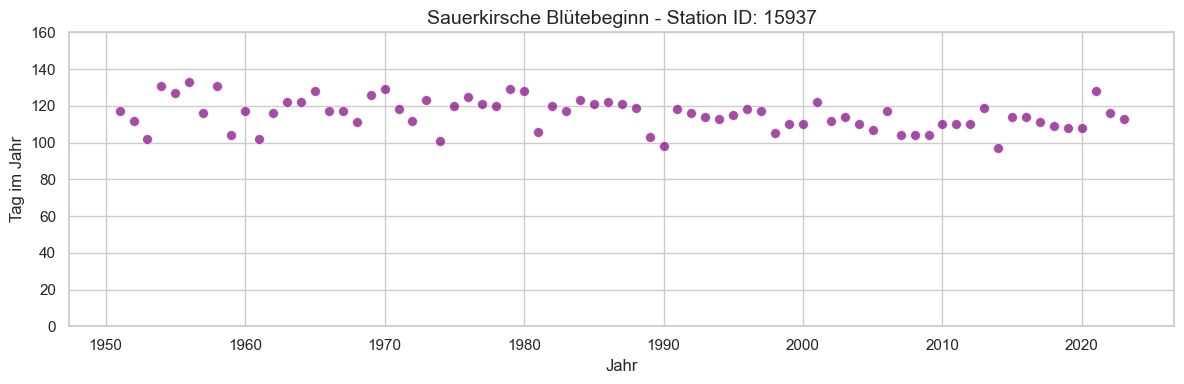

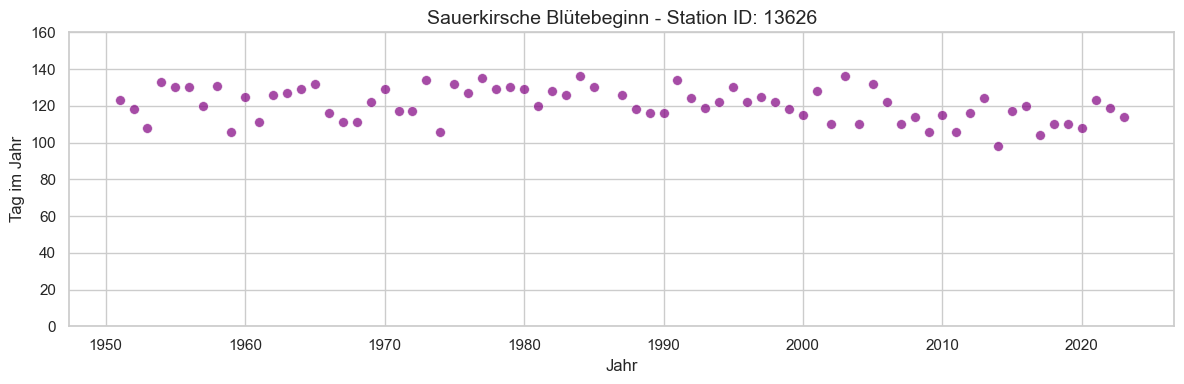

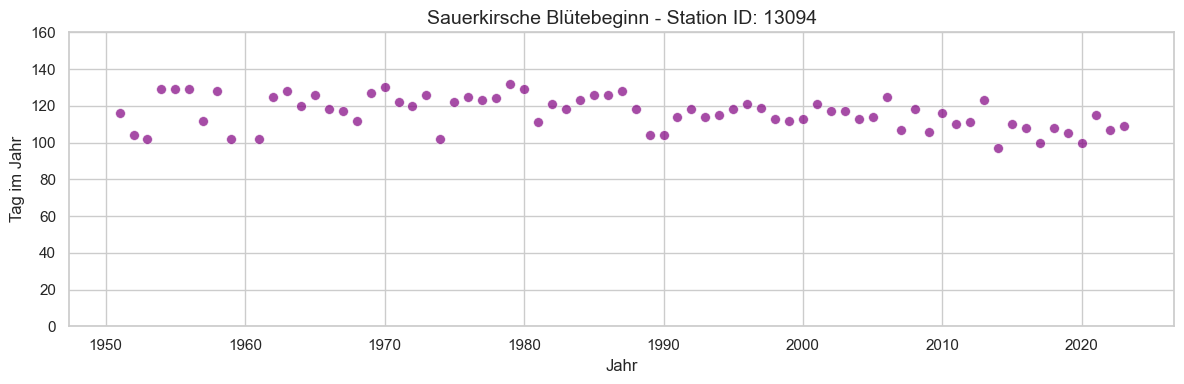

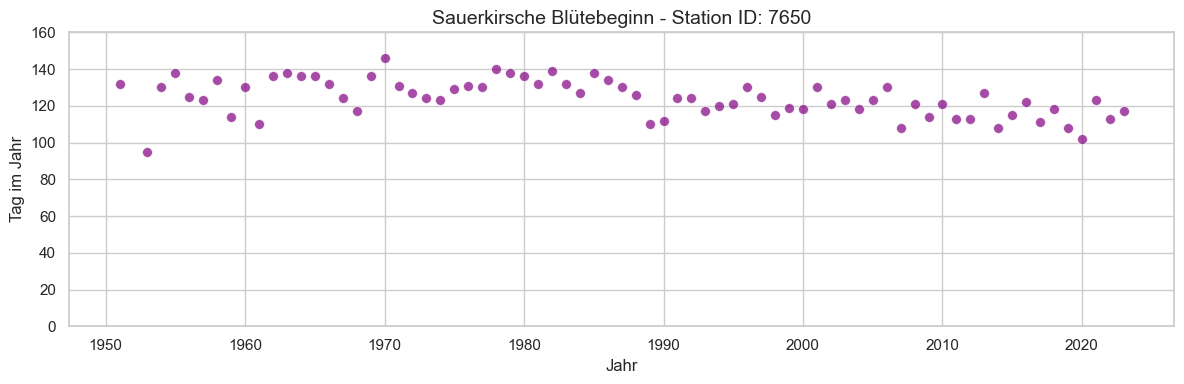

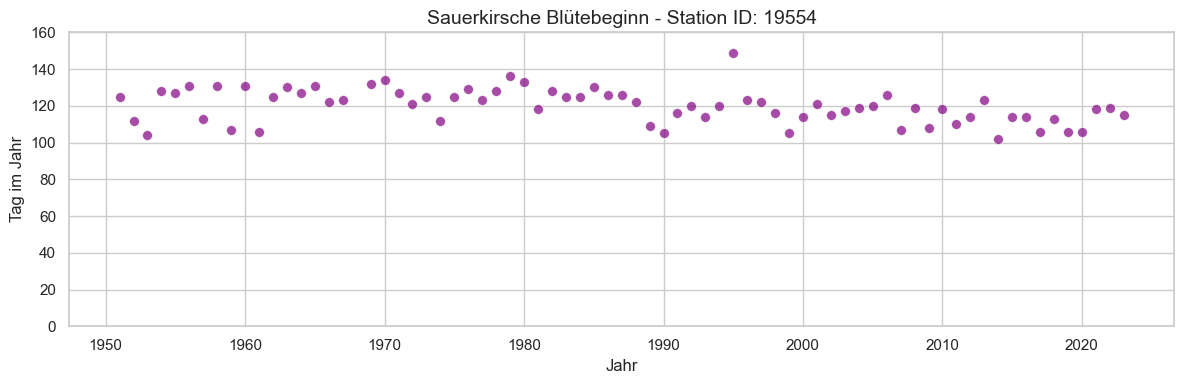

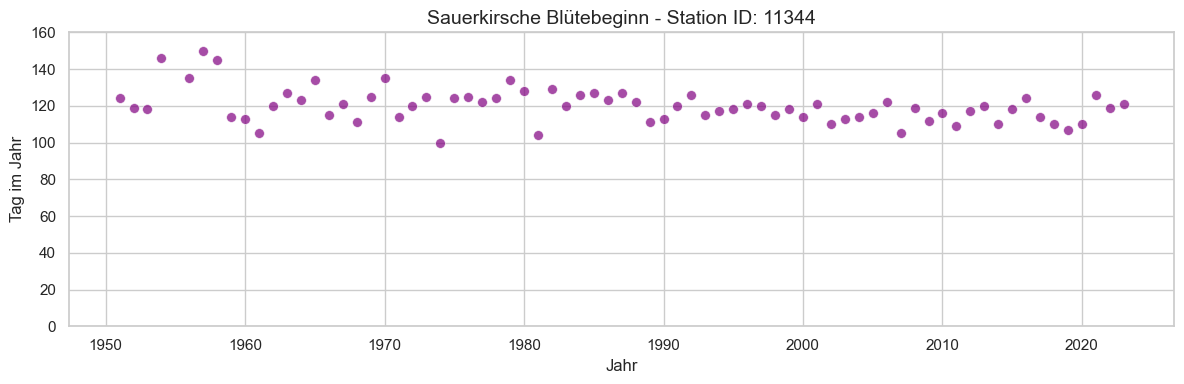

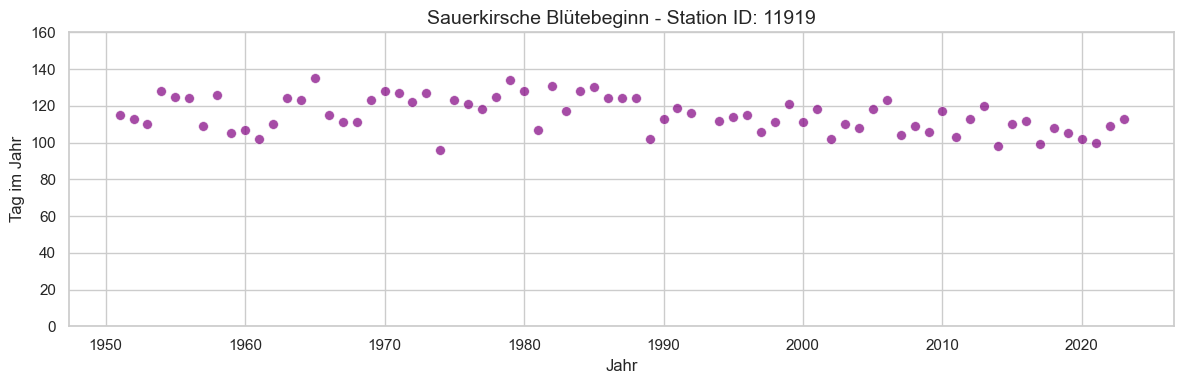

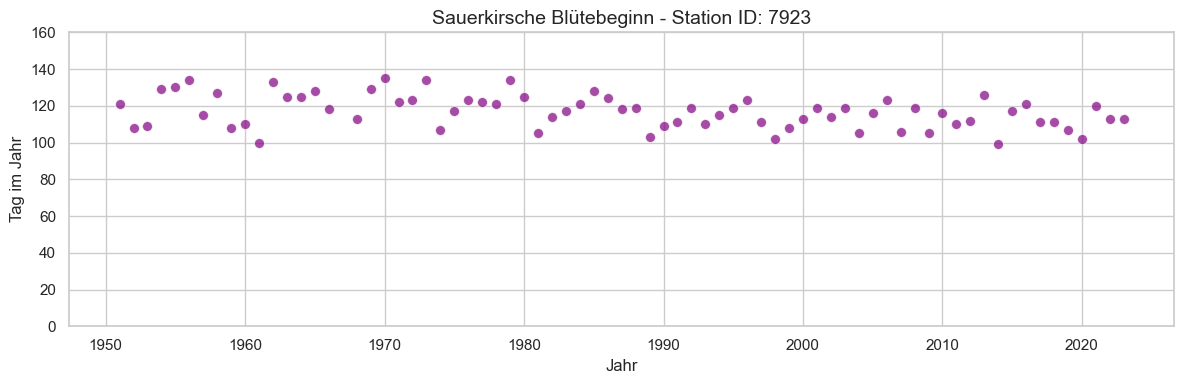

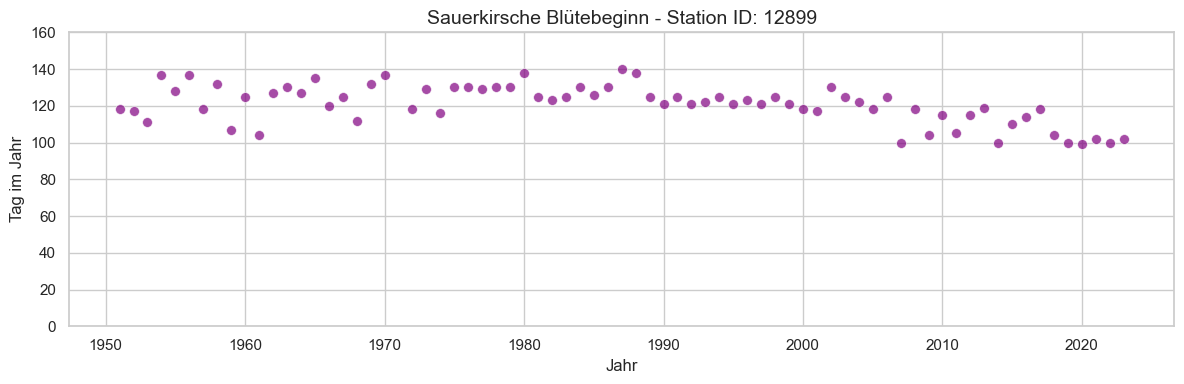

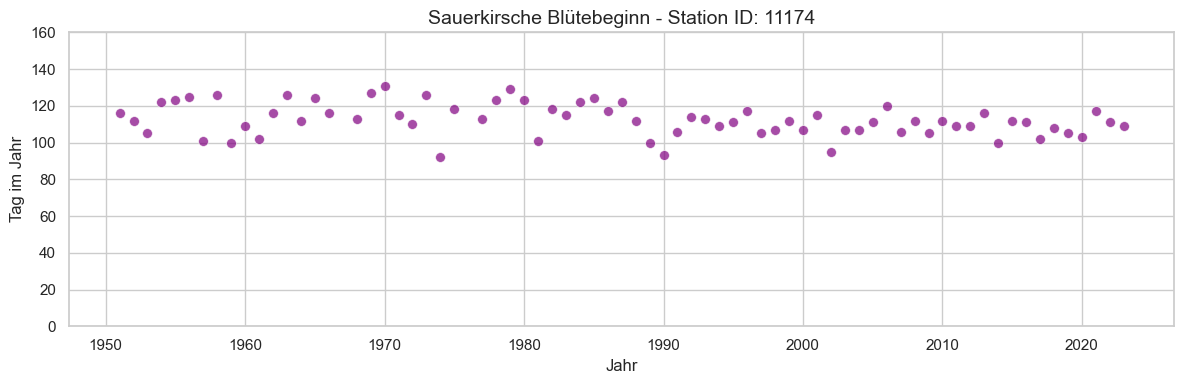

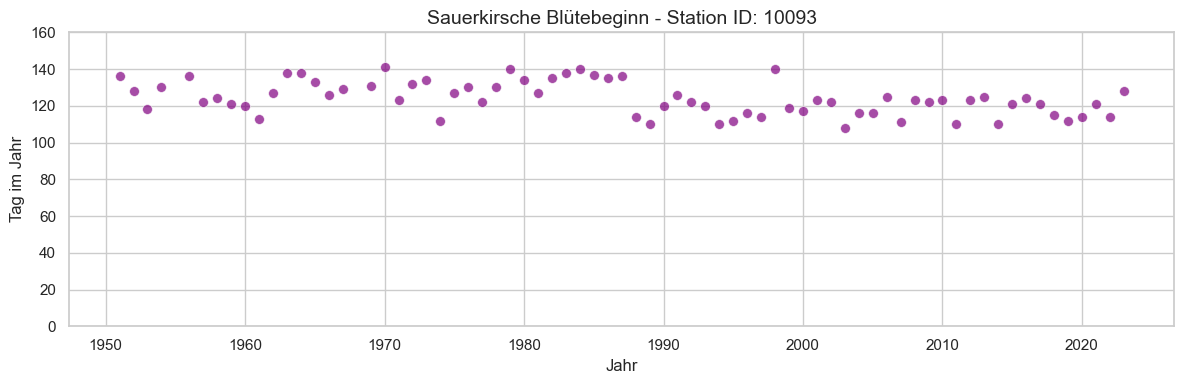

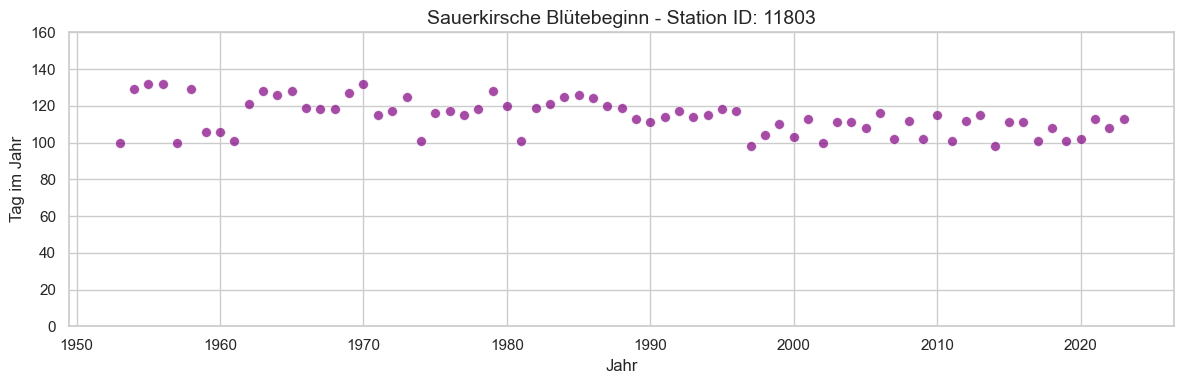

In [9]:
# To avoid crashing the browser with 1200+ plots, we select the top 20 longest running stations
station_counts = df['Stations_id'].value_counts()
top_stations = station_counts.head(20).index.tolist()
df_top = df[df['Stations_id'].isin(top_stations)]

# Determine a uniform y-axis scale for all charts
global_y_max = df_top['Jultag'].max() + 10

for station_id in top_stations:
    station_df = df_top[df_top['Stations_id'] == station_id]
    
    plt.figure(figsize=(12, 4))
    sns.scatterplot(
        data=station_df, 
        x='Referenzjahr', 
        y='Jultag', 
        color='purple',
        s=50,
        alpha=0.7
    )
    
    plt.title(f'Sauerkirsche Blütebeginn - Station ID: {station_id}', fontsize=14)
    plt.xlabel('Jahr', fontsize=12)
    plt.ylabel('Tag im Jahr', fontsize=12)
    plt.ylim(0, global_y_max)
    plt.tight_layout()
    plt.show()